# Stacking TransUNet для сегментации пор на DRP-421

Ноутбук повторяет пайплайн сегментации на DRP-421, но добавляет яркостный pixel classifier и stacking-ансамбль поверх уже обученного `TransUNet`.

Шаги пайплайна:
1. обучается brightness-based classifier по одиночной яркости пикселя;
2. загружается базовая `TransUNet`-модель из основного ноутбука сегментации;
3. поверх неё дообучается stacked-модель, которая использует исходное изображение, prior от pixel classifier и предсказание базового `TransUNet`.


In [1]:
from pathlib import Path
import sys

SHARED_PROJECT_ROOT = Path("/big_data/aleksey/CoreUNet")
PROJECT_ROOT = SHARED_PROJECT_ROOT

def resolve_transunet_import_root(project_root: Path) -> tuple[Path, Path]:
    candidate_dirs = [
        project_root / "external" / "TransUNet",
        project_root / "TransUNet",
        project_root / "external" / "TransUNet" / "TransUNet",
    ]
    for candidate in candidate_dirs:
        marker = candidate / "networks" / "vit_seg_modeling.py"
        if marker.exists():
            return candidate, candidate

    for marker in project_root.rglob("vit_seg_modeling.py"):
        if marker.parent.name == "networks":
            return marker.parent.parent, marker.parent.parent

    raise FileNotFoundError(
        f"Could not locate TransUNet import root under {project_root}. Expected networks/vit_seg_modeling.py"
    )

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Shared project root was not found: {PROJECT_ROOT}")

TRANSUNET_DIR, TRANSUNET_IMPORT_ROOT = resolve_transunet_import_root(PROJECT_ROOT)

if str(TRANSUNET_IMPORT_ROOT) not in sys.path:
    sys.path.insert(0, str(TRANSUNET_IMPORT_ROOT))

print(f"Shared project root: {PROJECT_ROOT}")
print(f"TransUNet directory: {TRANSUNET_DIR}")
print(f"TransUNet import root: {TRANSUNET_IMPORT_ROOT}")

Shared project root: /big_data/aleksey/CoreUNet
TransUNet directory: /big_data/aleksey/CoreUNet/external/TransUNet
TransUNet import root: /big_data/aleksey/CoreUNet/external/TransUNet


In [2]:
import math
import random
import zipfile
from collections import defaultdict
from datetime import datetime

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from IPython.display import display
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report, f1_score, jaccard_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from networks.vit_seg_modeling import CONFIGS, VisionTransformer

/opt/venvs/corecore-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.style.use("seaborn-v0_8")

SEED = 42
IMAGE_SIZE = 224
PATCH_SIZE = 200
BATCH_SIZE = 8
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

CLASSIFIER_INIT_INTENSITY_THRESHOLD = 0.50
CLASSIFIER_INIT_SHARPNESS = 12.0
CLASSIFIER_DECISION_THRESHOLD = 0.35
CLASSIFIER_LOSS_WEIGHT = 0.35
STACKING_NUM_EPOCHS = 5
STACKING_LEARNING_RATE = 5e-5

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Using device: {DEVICE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")


Using device: cuda:0
Patch size: 200x200


In [4]:
DATA_ROOT = PROJECT_ROOT / "data" / "drp421"
ARCHIVE_PATH = DATA_ROOT / "DRP-421_archive.zip"
EXTRACT_DIR = DATA_ROOT / "extracted"
NC_CACHE_DIR = DATA_ROOT / "nc_cache"
BASE_SEGMENTATION_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "transunet_segmentation_drp421"
BASE_CHECKPOINT_DIR = BASE_SEGMENTATION_ARTIFACTS_DIR / "checkpoints"
BASE_BEST_CHECKPOINT_PATH = BASE_CHECKPOINT_DIR / "best_checkpoint.pt"
BASE_BEST_MODEL_PATH = BASE_CHECKPOINT_DIR / "best_model_state.pth"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs" / "transunet_segmentation_drp421_stacking"
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUTS_ROOT / RUN_STAMP
WEIGHTS_DIR = RUN_DIR / "weights"
PREDICTION_DIR = RUN_DIR / "predictions"
METRICS_DIR = RUN_DIR / "metrics"
PLOTS_DIR = RUN_DIR / "plots"
BEST_CHECKPOINT_PATH = WEIGHTS_DIR / "best_checkpoint.pt"
LATEST_CHECKPOINT_PATH = WEIGHTS_DIR / "latest_checkpoint.pt"
BEST_MODEL_PATH = WEIGHTS_DIR / "best_model_state.pth"
CLASSIFIER_STATE_PATH = WEIGHTS_DIR / "threshold_classifier_state.npz"
TRAINING_HISTORY_PATH = METRICS_DIR / "training_history.csv"
VALIDATION_METRICS_PATH = METRICS_DIR / "validation_metrics.csv"
VALIDATION_REPORT_PATH = METRICS_DIR / "validation_report.txt"
PREDICTION_ARCHIVE_PATH = PREDICTION_DIR / "validation_predictions.npz"
PREDICTION_INDEX_PATH = PREDICTION_DIR / "validation_prediction_index.csv"
TRAINING_SAMPLES_FIGURE_PATH = PLOTS_DIR / "training_samples.png"
CLASSIFIER_METRICS_FIGURE_PATH = PLOTS_DIR / "classifier_metrics.png"
CLASSIFIER_ROC_FIGURE_PATH = PLOTS_DIR / "classifier_roc_curve.png"
ENSEMBLE_METRICS_FIGURE_PATH = PLOTS_DIR / "ensemble_metrics.png"
ENSEMBLE_ROC_FIGURE_PATH = PLOTS_DIR / "ensemble_roc_curve.png"
PREVIEW_FIGURE_PATH = PLOTS_DIR / "stacked_validation_preview.png"

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset directory was not found: {DATA_ROOT}")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
NC_CACHE_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run output directory: {RUN_DIR}")

SAMPLE_SPECS = [
    {
        "sample_name": "Bentheimer",
        "image_zip": "Bentheimer Sandstone/Bentheimer_Tomogram/tomo_R_SSw_SS_nc.zip",
        "mask_zip": "Bentheimer Sandstone/Bentheimer_Segmentation/BHG1eff_tst_phase.nc.zip",
        "pore_label": 1,
    },
    {
        "sample_name": "Leopard",
        "image_zip": "Leopard Sandstone/Leopard_Tomogram/tomoHiRes_SS_nc.zip",
        "mask_zip": "Leopard Sandstone/Leopard_Segmentation/LP_seg_800.nc.zip",
        "pore_label": 0,
    },
    {
        "sample_name": "Castlegate",
        "image_zip": "Castlegate Sandstone/Castlegate_Tomogram/CG_tomo.zip",
        "mask_zip": "Castlegate Sandstone/Castlegate_Segmentation/CG_seg_800.nc.zip",
        "pore_label": 1,
    },
]

def extract_main_archive(archive_path: Path, extract_dir: Path):
    archive_root = extract_dir / "DRP-421"
    if archive_root.exists():
        print(f"Using extracted archive: {archive_root}")
        return archive_root
    if any(extract_dir.iterdir()):
        print(f"Reusing existing extraction directory: {extract_dir}")
        return extract_dir
    if not archive_path.exists():
        raise FileNotFoundError(f"Main dataset archive was not found: {archive_path}")
    print(f"Extracting existing archive {archive_path} -> {extract_dir}")
    with zipfile.ZipFile(archive_path) as zf:
        zf.extractall(extract_dir)
    return archive_root if archive_root.exists() else extract_dir

def resolve_data_path(extract_root: Path, relative_path: str) -> Path:
    direct_path = extract_root / relative_path
    archive_root_path = extract_root / "DRP-421" / relative_path
    if direct_path.exists():
        return direct_path
    if archive_root_path.exists():
        return archive_root_path
    candidates = sorted(extract_root.rglob(Path(relative_path).name))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Could not resolve {relative_path} inside {extract_root}")

def extract_nc_from_nested_zip(nested_zip_path: Path, cache_dir: Path) -> list[Path]:
    target_dir = cache_dir / nested_zip_path.stem
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(nested_zip_path) as zf:
        nc_members = sorted(name for name in zf.namelist() if name.endswith(".nc"))
        if not nc_members:
            raise FileNotFoundError(f"No .nc file found inside {nested_zip_path}")
        existing_nc = {path.name: path for path in target_dir.rglob("*.nc")}
        if all(Path(member).name in existing_nc for member in nc_members):
            return [existing_nc[Path(member).name] for member in nc_members]
        extracted_files = []
        for member in nc_members:
            member_name = Path(member).name
            if member_name in existing_nc:
                extracted_files.append(existing_nc[member_name])
                continue
            zf.extract(member, target_dir)
            extracted = target_dir / member
            extracted_files.append(extracted)
    return extracted_files

def open_nc_dataarray(nc_path: Path):
    ds = xr.open_dataset(nc_path, engine="netcdf4")
    candidate_vars = [name for name, da in ds.data_vars.items() if da.ndim >= 3]
    if not candidate_vars:
        ds.close()
        raise ValueError(f"No 3D variable found in {nc_path}")

    data_array = ds[candidate_vars[0]].squeeze()
    while data_array.ndim > 3:
        data_array = data_array.isel({data_array.dims[0]: 0}).squeeze()
    return ds, data_array

def open_nc_volume(nc_paths):
    if isinstance(nc_paths, (str, Path)):
        nc_paths = [nc_paths]
    datasets = []
    arrays = []
    slice_counts = []
    spatial_shape = None
    for nc_path in nc_paths:
        ds, data_array = open_nc_dataarray(Path(nc_path))
        current_shape = tuple(int(x) for x in data_array.shape[1:])
        if spatial_shape is None:
            spatial_shape = current_shape
        elif current_shape != spatial_shape:
            raise ValueError(f"Spatial shape mismatch inside volume {nc_paths}: {current_shape} vs {spatial_shape}")
        datasets.append(ds)
        arrays.append(data_array)
        slice_counts.append(int(data_array.shape[0]))
    return {
        "datasets": datasets,
        "arrays": arrays,
        "slice_counts": slice_counts,
        "n_slices": int(sum(slice_counts)),
        "spatial_shape": spatial_shape,
    }

def close_nc_volume(volume):
    for ds in volume["datasets"]:
        ds.close()

def get_volume_slice(volume, slice_idx: int):
    local_idx = int(slice_idx)
    for data_array, slice_count in zip(volume["arrays"], volume["slice_counts"]):
        if local_idx < slice_count:
            return np.asarray(data_array.isel({data_array.dims[0]: local_idx}).values)
        local_idx -= slice_count
    raise IndexError(f"Slice index {slice_idx} is out of range for volume with {volume['n_slices']} slices")

class CoreSliceDataset(Dataset):
    def __init__(self, records, transform=None, patch_size: int | None = None):
        self.records = list(records)
        self.transform = transform
        self.patch_size = patch_size
        self._cache = {}

    def __len__(self):
        return len(self.records)

    def _get_array(self, nc_paths):
        cache_key = tuple(nc_paths) if isinstance(nc_paths, (list, tuple)) else (str(nc_paths),)
        if cache_key not in self._cache:
            self._cache[cache_key] = open_nc_volume(list(cache_key))
        return self._cache[cache_key]

    @staticmethod
    def _normalize_image(image: np.ndarray) -> np.ndarray:
        image = np.nan_to_num(image.astype(np.float32))
        image_min = float(image.min())
        image_max = float(image.max())
        if image_max > image_min:
            image = (image - image_min) / (image_max - image_min)
        else:
            image = np.zeros_like(image, dtype=np.float32)
        return image

    def _extract_patch(self, image: np.ndarray, mask: np.ndarray, record: dict):
        original_height = int(record.get("original_height", image.shape[0]))
        original_width = int(record.get("original_width", image.shape[1]))
        patch_top = int(record.get("patch_top", 0))
        patch_left = int(record.get("patch_left", 0))
        valid_height = int(record.get("valid_height", original_height))
        valid_width = int(record.get("valid_width", original_width))
        target_patch_size = int(record.get("patch_size", self.patch_size or max(valid_height, valid_width)))

        image_patch = image[patch_top : patch_top + valid_height, patch_left : patch_left + valid_width].astype(np.float32)
        mask_patch = mask[patch_top : patch_top + valid_height, patch_left : patch_left + valid_width].astype(np.uint8)
        valid_region = np.ones((valid_height, valid_width), dtype=np.uint8)

        pad_bottom = max(target_patch_size - valid_height, 0)
        pad_right = max(target_patch_size - valid_width, 0)
        if pad_bottom > 0 or pad_right > 0:
            if image_patch.size:
                image_patch = np.pad(image_patch, ((0, pad_bottom), (0, pad_right)), mode="edge")
            else:
                image_patch = np.pad(image_patch, ((0, pad_bottom), (0, pad_right)), mode="constant", constant_values=0)
            mask_patch = np.pad(mask_patch, ((0, pad_bottom), (0, pad_right)), mode="constant", constant_values=0)
            valid_region = np.pad(valid_region, ((0, pad_bottom), (0, pad_right)), mode="constant", constant_values=0)

        return image_patch.astype(np.float32), mask_patch.astype(np.uint8), valid_region.astype(np.uint8)

    def __getitem__(self, idx):
        record = self.records[idx]
        image_volume = self._get_array(record["image_nc"])
        mask_volume = self._get_array(record["mask_nc"])

        image = get_volume_slice(image_volume, record["slice_idx"])
        mask = get_volume_slice(mask_volume, record["slice_idx"])

        image = self._normalize_image(image)
        mask = (mask == record["pore_label"]).astype(np.uint8)
        image_patch, mask_patch, valid_region = self._extract_patch(image, mask, record)

        image_native = image_patch.copy()
        mask_native = mask_patch.copy()
        valid_region_native = valid_region.copy()

        if self.transform is not None:
            augmented = self.transform(image=image_patch, mask=mask_patch, valid_region=valid_region)
            image_patch = augmented["image"]
            mask_patch = augmented["mask"].long()
            valid_region = augmented["valid_region"].float()

        return {
            "image": image_patch,
            "mask": mask_patch,
            "valid_region": valid_region,
            "image_native": image_native,
            "mask_native": mask_native,
            "valid_region_native": valid_region_native,
            "sample_name": record["sample_name"],
            "slice_idx": int(record["slice_idx"]),
            "patch_top": int(record.get("patch_top", 0)),
            "patch_left": int(record.get("patch_left", 0)),
            "valid_height": int(record.get("valid_height", image.shape[0])),
            "valid_width": int(record.get("valid_width", image.shape[1])),
            "original_height": int(record.get("original_height", image.shape[0])),
            "original_width": int(record.get("original_width", image.shape[1])),
            "patch_size": int(record.get("patch_size", self.patch_size or max(image.shape))),
        }


Run output directory: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923


In [5]:
DATA_EXTRACT_ROOT = extract_main_archive(ARCHIVE_PATH, EXTRACT_DIR)

sample_entries = []
skipped_samples = []
for spec in SAMPLE_SPECS:
    image_nested_zip = resolve_data_path(DATA_EXTRACT_ROOT, spec["image_zip"])
    mask_nested_zip = resolve_data_path(DATA_EXTRACT_ROOT, spec["mask_zip"])
    image_nc = extract_nc_from_nested_zip(image_nested_zip, NC_CACHE_DIR)
    mask_nc = extract_nc_from_nested_zip(mask_nested_zip, NC_CACHE_DIR)

    image_volume = open_nc_volume(image_nc)
    mask_volume = open_nc_volume(mask_nc)
    image_shape = (image_volume["n_slices"], *image_volume["spatial_shape"])
    mask_shape = (mask_volume["n_slices"], *mask_volume["spatial_shape"])
    if image_shape != mask_shape:
        skipped_samples.append(
            {
                "sample_name": spec["sample_name"],
                "image_shape": image_shape,
                "mask_shape": mask_shape,
            }
        )
        print(
            f"Skipping {spec['sample_name']}: image and mask volumes are not co-registered ({image_shape} vs {mask_shape})"
        )
        close_nc_volume(image_volume)
        close_nc_volume(mask_volume)
        continue

    n_slices = image_volume["n_slices"]
    spatial_shape = tuple(int(x) for x in image_volume["spatial_shape"])
    close_nc_volume(image_volume)
    close_nc_volume(mask_volume)

    sample_entries.append(
        {
            "sample_name": spec["sample_name"],
            "image_nc": [str(path) for path in image_nc],
            "mask_nc": [str(path) for path in mask_nc],
            "pore_label": spec["pore_label"],
            "n_slices": n_slices,
            "spatial_shape": spatial_shape,
        }
    )

all_records = []
for entry in sample_entries:
    original_height, original_width = entry["spatial_shape"]
    for slice_idx in range(entry["n_slices"]):
        all_records.append(
            {
                "sample_name": entry["sample_name"],
                "image_nc": entry["image_nc"],
                "mask_nc": entry["mask_nc"],
                "pore_label": entry["pore_label"],
                "slice_idx": slice_idx,
                "original_height": original_height,
                "original_width": original_width,
            }
        )

def build_patch_records(records, patch_size: int):
    patch_records = []
    for record in records:
        original_height = int(record["original_height"])
        original_width = int(record["original_width"])
        for patch_top in range(0, original_height, patch_size):
            for patch_left in range(0, original_width, patch_size):
                patch_records.append(
                    {
                        **record,
                        "patch_top": patch_top,
                        "patch_left": patch_left,
                        "valid_height": min(patch_size, original_height - patch_top),
                        "valid_width": min(patch_size, original_width - patch_left),
                        "patch_size": patch_size,
                    }
                )
    return patch_records

if not sample_entries:
    raise ValueError("No co-registered image/mask pairs were found in DRP-421.")
if skipped_samples:
    print(pd.DataFrame(skipped_samples).to_string(index=False))

records_df = pd.DataFrame(all_records)
train_df, val_df = train_test_split(
    records_df,
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
    stratify=records_df["sample_name"],
)

train_records = train_df.to_dict("records")
val_records = val_df.to_dict("records")
train_patch_records = build_patch_records(train_records, PATCH_SIZE)
val_patch_records = build_patch_records(val_records, PATCH_SIZE)

print(f"Total slices: {len(records_df)}")
print(f"Train slices: {len(train_records)}")
print(f"Validation slices: {len(val_records)}")
print(f"Train patches: {len(train_patch_records)}")
print(f"Validation patches: {len(val_patch_records)}")
display(records_df.groupby("sample_name").size().rename("slice_count").to_frame())


Using extracted archive: /big_data/aleksey/CoreUNet/data/drp421/extracted/DRP-421
Skipping Castlegate: image and mask volumes are not co-registered ((360, 1240, 1240) vs (800, 800, 800))
sample_name       image_shape      mask_shape
 Castlegate (360, 1240, 1240) (800, 800, 800)
Total slices: 1600
Train slices: 1360
Validation slices: 240
Train patches: 21760
Validation patches: 3840


,slice_count
sample_name,
Bentheimer,800
Leopard,800


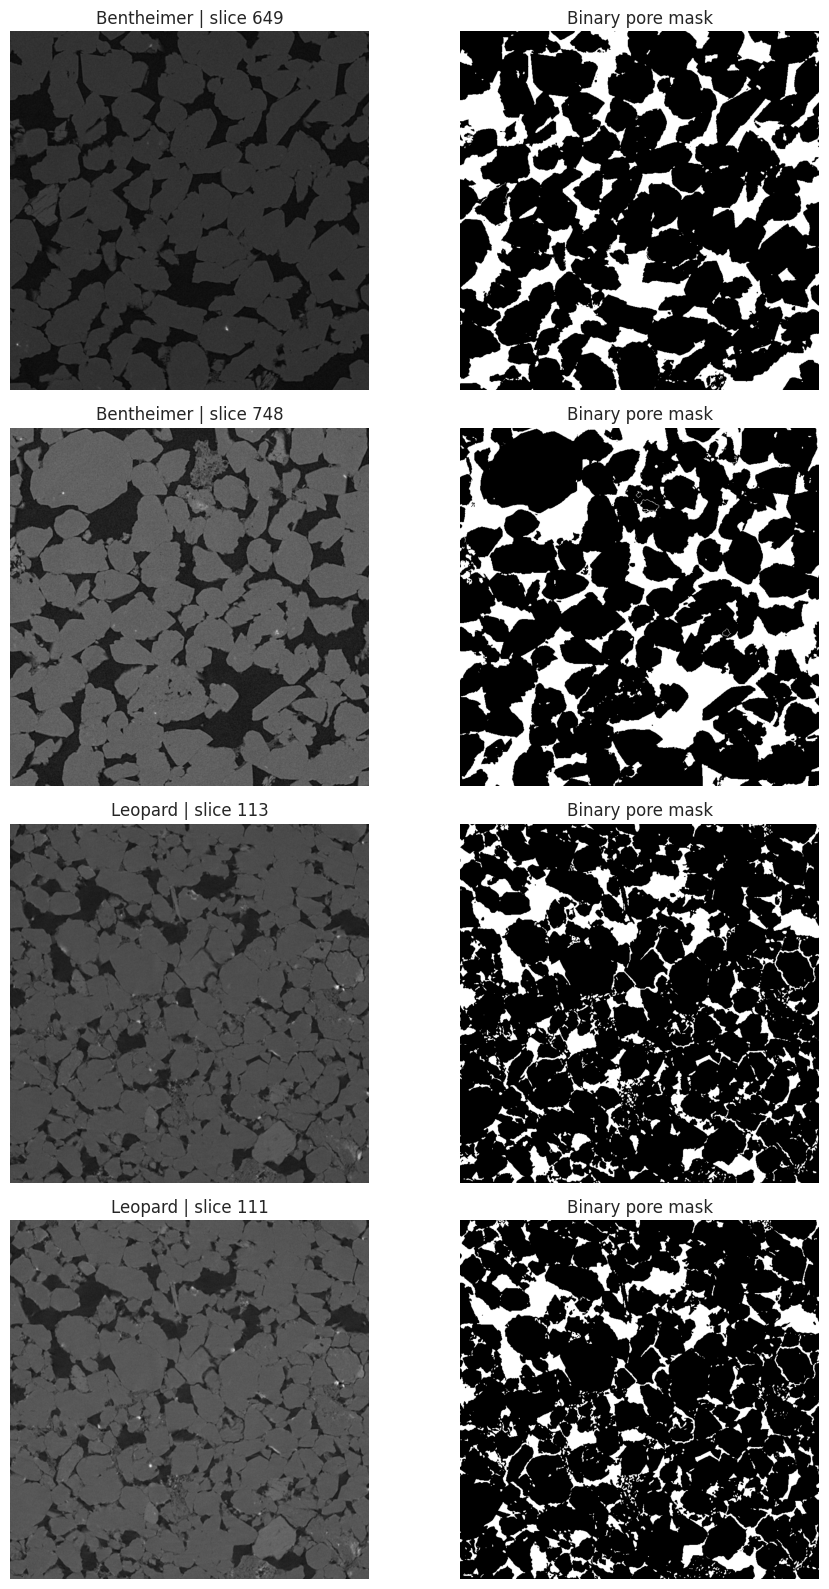

Saved training sample figure to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/plots/training_samples.png


In [6]:
raw_dataset = CoreSliceDataset(train_records, transform=None)
sample_indices = np.random.choice(len(raw_dataset), size=min(4, len(raw_dataset)), replace=False)

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(10, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, dataset_idx in enumerate(sample_indices):
    sample = raw_dataset[dataset_idx]
    image = sample["image"]
    mask = sample["mask"]

    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title(f"{sample['sample_name']} | slice {sample['slice_idx']}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Binary pore mask")
    axes[row, 1].axis("off")

plt.tight_layout()
fig.savefig(TRAINING_SAMPLES_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved training sample figure to {TRAINING_SAMPLES_FIGURE_PATH}")

In [8]:
def compute_mean_std(records, patch_size: int):
    probe_dataset = CoreSliceDataset(records, transform=None, patch_size=patch_size)
    pixel_sum = 0.0
    pixel_sq_sum = 0.0
    pixel_count = 0

    for record in tqdm(records, desc="Computing mean/std over patches"):
        image_volume = probe_dataset._get_array(record["image_nc"])
        image = probe_dataset._normalize_image(
            get_volume_slice(image_volume, record["slice_idx"])
        )
        dummy_mask = np.zeros_like(image, dtype=np.uint8)
        image_patch, _, valid_region = probe_dataset._extract_patch(image, dummy_mask, record)
        valid_pixels = image_patch[valid_region > 0]
        if valid_pixels.size == 0:
            continue
        pixel_sum += float(valid_pixels.sum())
        pixel_sq_sum += float((valid_pixels ** 2).sum())
        pixel_count += int(valid_pixels.size)

    if pixel_count == 0:
        raise ValueError("Could not compute normalization statistics because no valid patch pixels were found.")

    mean_value = pixel_sum / pixel_count
    variance_value = max(pixel_sq_sum / pixel_count - mean_value ** 2, 1e-8)
    std_value = math.sqrt(variance_value)
    return [float(mean_value)], [float(std_value)]

In [10]:
train_mean, train_std = compute_mean_std(train_patch_records, PATCH_SIZE)
print(f"Normalization mean vector: {train_mean}")
print(f"Normalization std vector: {train_std}")
print(f"Classifier decision threshold: {CLASSIFIER_DECISION_THRESHOLD:.2f}")

additional_targets = {"valid_region": "mask"}
train_transform = A.Compose(
    [
        A.Rotate(limit=25, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
        A.GaussNoise(var_limit=(10.0, 50.0), mean=0, p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.Normalize(mean=train_mean, std=train_std, max_pixel_value=1.0),
        ToTensorV2(transpose_mask=False),
    ],
    additional_targets=additional_targets,
)

val_transform = A.Compose(
    [
        A.Resize(IMAGE_SIZE, IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.Normalize(mean=train_mean, std=train_std, max_pixel_value=1.0),
        ToTensorV2(transpose_mask=False),
    ],
    additional_targets=additional_targets,
)

train_dataset = CoreSliceDataset(train_patch_records, transform=train_transform, patch_size=PATCH_SIZE)
val_dataset = CoreSliceDataset(val_patch_records, transform=val_transform, patch_size=PATCH_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda:0",
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda:0",
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Computing mean/std over patches: 100%|██████████| 21760/21760 [00:26<00:00, 814.00it/s]

Normalization mean vector: [0.2962354612162534]
Normalization std vector: [0.21639223732854693]
Classifier decision threshold: 0.35
Train batches: 2720
Validation batches: 480



/workspace/.ts/tmp/ipykernel_73700/2850496045.py:10: UserWarning: Argument(s) 'var_limit, mean' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), mean=0, p=0.3),


In [11]:
def safe_roc_auc(y_true, y_score):
    unique_targets = np.unique(y_true)
    if unique_targets.size < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def masked_bce_with_logits(logits, targets, valid_mask, eps: float = 1e-6):
    valid_mask = valid_mask.float()
    loss = F.binary_cross_entropy_with_logits(logits, targets.float(), reduction="none")
    return (loss * valid_mask).sum() / valid_mask.sum().clamp_min(eps)

def masked_cross_entropy(logits, targets, valid_mask, eps: float = 1e-6):
    valid_mask = valid_mask.float()
    loss = F.cross_entropy(logits, targets, reduction="none")
    return (loss * valid_mask).sum() / valid_mask.sum().clamp_min(eps)

class SoftDiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets, valid_mask=None):
        probs = torch.softmax(logits, dim=1)[:, 1]
        targets = targets.float()
        if valid_mask is None:
            valid_mask = torch.ones_like(targets, dtype=torch.float32)
        valid_mask = valid_mask.float()

        probs = probs * valid_mask
        targets = targets * valid_mask
        intersection = (probs * targets).sum(dim=(1, 2))
        denominator = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
        dice = (2.0 * intersection + self.eps) / (denominator + self.eps)
        return 1.0 - dice.mean()

def ensure_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)

def resize_patch_map(patch_map: np.ndarray, target_patch_size: int, interpolation: int):
    return cv2.resize(
        patch_map.astype(np.float32),
        (target_patch_size, target_patch_size),
        interpolation=interpolation,
    )

def create_reconstruction_entry(sample_name: str, slice_idx: int, original_height: int, original_width: int):
    shape = (original_height, original_width)
    return {
        "sample_name": sample_name,
        "slice_idx": slice_idx,
        "image": np.zeros(shape, dtype=np.float32),
        "mask": np.zeros(shape, dtype=np.uint8),
        "classifier_prob": np.zeros(shape, dtype=np.float32),
        "classifier_prior": np.zeros(shape, dtype=np.float32),
        "base_prob": np.zeros(shape, dtype=np.float32),
        "ensemble_prob": np.zeros(shape, dtype=np.float32),
        "pred": np.zeros(shape, dtype=np.uint8),
    }

def stitch_batch_predictions(reconstructed_slices: dict, batch: dict, classifier_prob, classifier_prior, base_prob, ensemble_prob):
    image_native = ensure_numpy(batch["image_native"]).astype(np.float32)
    mask_native = ensure_numpy(batch["mask_native"]).astype(np.uint8)
    sample_names = list(batch["sample_name"])
    slice_indices = ensure_numpy(batch["slice_idx"]).astype(np.int32)
    patch_tops = ensure_numpy(batch["patch_top"]).astype(np.int32)
    patch_lefts = ensure_numpy(batch["patch_left"]).astype(np.int32)
    valid_heights = ensure_numpy(batch["valid_height"]).astype(np.int32)
    valid_widths = ensure_numpy(batch["valid_width"]).astype(np.int32)
    original_heights = ensure_numpy(batch["original_height"]).astype(np.int32)
    original_widths = ensure_numpy(batch["original_width"]).astype(np.int32)
    patch_sizes = ensure_numpy(batch["patch_size"]).astype(np.int32)

    classifier_prob_np = ensure_numpy(classifier_prob.squeeze(1)).astype(np.float32)
    classifier_prior_np = ensure_numpy(classifier_prior.squeeze(1)).astype(np.float32)
    base_prob_np = ensure_numpy(base_prob.squeeze(1)).astype(np.float32)
    ensemble_prob_np = ensure_numpy(ensemble_prob.squeeze(1)).astype(np.float32)

    for idx, sample_name in enumerate(sample_names):
        slice_idx = int(slice_indices[idx])
        key = (sample_name, slice_idx)
        if key not in reconstructed_slices:
            reconstructed_slices[key] = create_reconstruction_entry(
                sample_name=sample_name,
                slice_idx=slice_idx,
                original_height=int(original_heights[idx]),
                original_width=int(original_widths[idx]),
            )

        patch_size = int(patch_sizes[idx])
        patch_top = int(patch_tops[idx])
        patch_left = int(patch_lefts[idx])
        valid_height = int(valid_heights[idx])
        valid_width = int(valid_widths[idx])

        classifier_prob_patch = resize_patch_map(classifier_prob_np[idx], patch_size, cv2.INTER_LINEAR)
        classifier_prior_patch = resize_patch_map(classifier_prior_np[idx], patch_size, cv2.INTER_LINEAR)
        base_prob_patch = resize_patch_map(base_prob_np[idx], patch_size, cv2.INTER_LINEAR)
        ensemble_prob_patch = resize_patch_map(ensemble_prob_np[idx], patch_size, cv2.INTER_LINEAR)
        pred_patch = (ensemble_prob_patch >= 0.5).astype(np.uint8)

        reconstructed_slices[key]["image"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = image_native[idx][:valid_height, :valid_width]
        reconstructed_slices[key]["mask"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = mask_native[idx][:valid_height, :valid_width]
        reconstructed_slices[key]["classifier_prob"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = classifier_prob_patch[:valid_height, :valid_width]
        reconstructed_slices[key]["classifier_prior"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = classifier_prior_patch[:valid_height, :valid_width]
        reconstructed_slices[key]["base_prob"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = base_prob_patch[:valid_height, :valid_width]
        reconstructed_slices[key]["ensemble_prob"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = ensemble_prob_patch[:valid_height, :valid_width]
        reconstructed_slices[key]["pred"][patch_top : patch_top + valid_height, patch_left : patch_left + valid_width] = pred_patch[:valid_height, :valid_width]

def flatten_reconstructed_slices(reconstructed_slices: dict):
    ordered_keys = sorted(reconstructed_slices.keys(), key=lambda item: (item[0], item[1]))
    ordered_predictions = [reconstructed_slices[key] for key in ordered_keys]
    if not ordered_predictions:
        raise ValueError("No reconstructed slices were produced from validation patches.")

    y_true = np.concatenate([item["mask"].reshape(-1) for item in ordered_predictions])
    classifier_prob_flat = np.concatenate([item["classifier_prob"].reshape(-1) for item in ordered_predictions])
    ensemble_prob_flat = np.concatenate([item["ensemble_prob"].reshape(-1) for item in ordered_predictions])
    y_pred = np.concatenate([item["pred"].reshape(-1) for item in ordered_predictions])
    return ordered_predictions, y_true, classifier_prob_flat, ensemble_prob_flat, y_pred

class LearnableThresholdClassifier(nn.Module):
    def __init__(
        self,
        init_intensity_threshold: float,
        init_sharpness: float,
        decision_threshold: float,
    ):
        super().__init__()
        self.intensity_threshold = nn.Parameter(torch.tensor(init_intensity_threshold, dtype=torch.float32))
        self.log_sharpness = nn.Parameter(torch.log(torch.tensor(init_sharpness, dtype=torch.float32)))
        self.register_buffer("decision_threshold", torch.tensor(decision_threshold, dtype=torch.float32).view(1, 1, 1, 1))

    def current_threshold(self):
        return torch.clamp(self.intensity_threshold, 0.0, 1.0)

    def current_sharpness(self):
        return torch.clamp(F.softplus(self.log_sharpness), min=1e-3)

    def forward(self, restored_images):
        threshold = self.current_threshold().view(1, 1, 1, 1)
        sharpness = self.current_sharpness().view(1, 1, 1, 1)
        classifier_logit = (threshold - restored_images) * sharpness
        classifier_prob = torch.sigmoid(classifier_logit)
        classifier_prior = torch.clamp(
            (classifier_prob - self.decision_threshold) / torch.clamp(1.0 - self.decision_threshold, min=1e-6),
            0.0,
            1.0,
        )
        return classifier_logit, classifier_prob, classifier_prior

class ThresholdStackedTransUNet(nn.Module):
    def __init__(
        self,
        base_model: nn.Module,
        threshold_classifier: LearnableThresholdClassifier,
        image_mean: float,
        image_std: float,
    ):
        super().__init__()
        self.base_model = base_model
        self.threshold_classifier = threshold_classifier
        self.register_buffer("image_mean", torch.tensor(image_mean, dtype=torch.float32).view(1, 1, 1, 1))
        self.register_buffer("image_std", torch.tensor(image_std, dtype=torch.float32).view(1, 1, 1, 1))
        self.fusion_head = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 2, kernel_size=1),
        )

    def restore_images(self, images):
        return torch.clamp(images[:, :1] * self.image_std + self.image_mean, 0.0, 1.0)

    def forward_with_aux(self, images):
        restored_images = self.restore_images(images)
        classifier_logit, classifier_prob, classifier_prior = self.threshold_classifier(restored_images)
        base_logits = self.base_model(images)
        base_pore_prob = torch.softmax(base_logits, dim=1)[:, 1:2]
        fusion_input = torch.cat(
            [
                restored_images,
                classifier_prior,
                base_pore_prob,
                classifier_prob,
            ],
            dim=1,
        )
        ensemble_logits = base_logits + self.fusion_head(fusion_input)
        ensemble_prob = torch.softmax(ensemble_logits, dim=1)[:, 1:2]
        return ensemble_logits, classifier_logit, classifier_prob, classifier_prior, base_pore_prob, ensemble_prob

    def forward(self, images):
        ensemble_logits, _, _, _, _, _ = self.forward_with_aux(images)
        return ensemble_logits

def build_checkpoint_payload(epoch: int, history, best_metric: float):
    return {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "config_name": "R50-ViT-B_16",
        "image_size": IMAGE_SIZE,
        "patch_size": PATCH_SIZE,
        "mean": train_mean,
        "std": train_std,
        "history": history,
        "best_val_dice": best_metric,
        "epoch": epoch,
        "run_dir": str(RUN_DIR),
        "classifier_decision_threshold": CLASSIFIER_DECISION_THRESHOLD,
        "classifier_intensity_threshold": float(model.threshold_classifier.current_threshold().detach().cpu()),
        "classifier_sharpness": float(model.threshold_classifier.current_sharpness().detach().cpu()),
        "base_checkpoint_path": str(BASE_BEST_CHECKPOINT_PATH),
    }

Loaded base TransUNet weights: /big_data/aleksey/CoreUNet/artifacts/transunet_segmentation_drp421/checkpoints/best_model_state.pth


Stacking epoch 1/5 [val]: 100%|██████████| 480/480 [00:55<00:00,  8.67it/s, classifier_loss=0.7858, ensemble_loss=0.1112]


{'epoch': 1, 'classifier_train_loss': 0.7805973018136094, 'classifier_val_loss': 0.7184969242662191, 'classifier_val_f1': 0.358607212700516, 'classifier_val_roc_auc': 0.7166432836149423, 'ensemble_train_loss': 0.35706518577302204, 'ensemble_val_loss': 0.16366062207768362, 'ensemble_val_iou': 0.8588557948396615, 'ensemble_val_dice': 0.9240693088984274, 'ensemble_val_roc_auc': 0.9938286770979521, 'classifier_intensity_threshold': 0.37190648913383484, 'classifier_sharpness': 2.472170352935791, 'validation_reconstructed_slices': 240}
Saved best stacking checkpoint to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_checkpoint.pt
Saved best stacking model weights to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_model_state.pth


Stacking epoch 2/5 [val]:  71%|███████▏  | 342/480 [00:40<00:16,  8.61it/s, classifier_loss=0.5399, ensemble_loss=0.0917]

Saved best stacking checkpoint to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_checkpoint.pt
Saved best stacking model weights to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_model_state.pth


Stacking epoch 3/5 [train]:  55%|█████▌    | 1499/2720 [08:02<06:31,  3.12it/s, classifier_loss=0.5899, ensemble_loss=0.4950]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Stacking epoch 4/5 [val]: 100%|██████████| 480/480 [00:54<00:00,  8.74it/s, classifier_loss=0.5337, ensemble_loss=0.0990]


{'epoch': 4, 'classifier_train_loss': 0.5650675039847984, 'classifier_val_loss': 0.5385760119805734, 'classifier_val_f1': 0.4963431770945294, 'classifier_val_roc_auc': 0.7168059474070742, 'ensemble_train_loss': 0.3264570355607087, 'ensemble_val_loss': 0.15259317342036713, 'ensemble_val_iou': 0.8664230903389462, 'ensemble_val_dice': 0.9284316024847313, 'ensemble_val_roc_auc': 0.9945234400509831, 'classifier_intensity_threshold': 0.022036608308553696, 'classifier_sharpness': 2.6341850757598877, 'validation_reconstructed_slices': 240}
Saved best stacking checkpoint to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_checkpoint.pt
Saved best stacking model weights to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_model_state.pth


Stacking epoch 5/5 [val]: 100%|██████████| 480/480 [00:54<00:00,  8.73it/s, classifier_loss=0.5195, ensemble_loss=0.1016]


{'epoch': 5, 'classifier_train_loss': 0.5407748761860763, 'classifier_val_loss': 0.5311526391655207, 'classifier_val_f1': 0.5298789360404961, 'classifier_val_roc_auc': 0.7168238927177909, 'ensemble_train_loss': 0.3198295534506221, 'ensemble_val_loss': 0.15141707045647004, 'ensemble_val_iou': 0.8656509142966577, 'ensemble_val_dice': 0.927988090015226, 'ensemble_val_roc_auc': 0.9944898462060981, 'classifier_intensity_threshold': 0.0, 'classifier_sharpness': 2.729076385498047, 'validation_reconstructed_slices': 240}


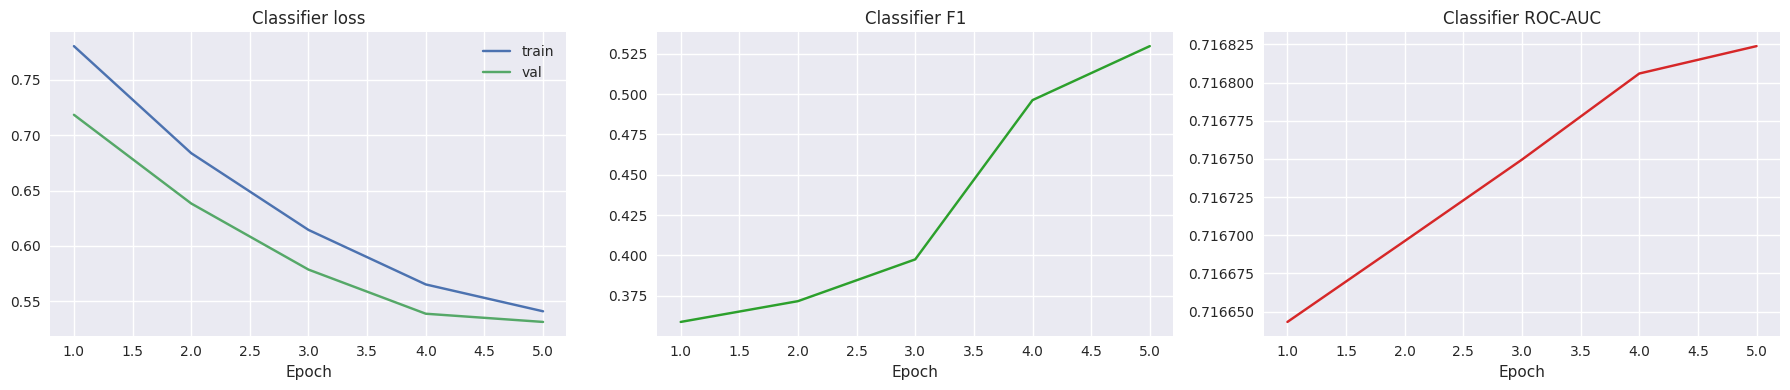

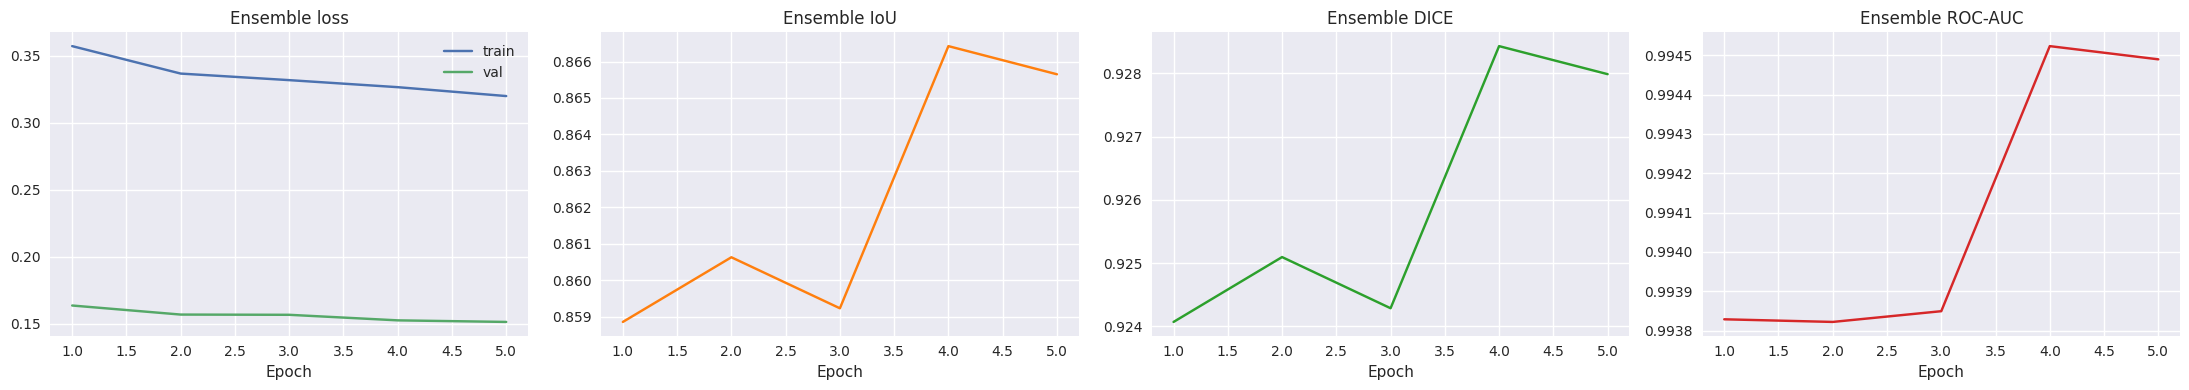

Latest stacking checkpoint: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/latest_checkpoint.pt
Best stacking checkpoint: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/weights/best_checkpoint.pt
Classifier metrics figure: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/plots/classifier_metrics.png
Ensemble metrics figure: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/plots/ensemble_metrics.png
Training history: /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/metrics/training_history.csv


In [13]:
vit_config = CONFIGS["R50-ViT-B_16"]
vit_config.n_classes = 2
vit_config.n_skip = 3
vit_config.patches.grid = (IMAGE_SIZE // 16, IMAGE_SIZE // 16)

base_model = VisionTransformer(vit_config, img_size=IMAGE_SIZE, num_classes=vit_config.n_classes).to(DEVICE)

if BASE_BEST_MODEL_PATH.exists():
    base_state = torch.load(BASE_BEST_MODEL_PATH, map_location=DEVICE)
    base_model.load_state_dict(base_state)
    print(f"Loaded base TransUNet weights: {BASE_BEST_MODEL_PATH}")
elif BASE_BEST_CHECKPOINT_PATH.exists():
    base_checkpoint = torch.load(BASE_BEST_CHECKPOINT_PATH, map_location=DEVICE)
    base_model.load_state_dict(base_checkpoint["model_state"])
    print(f"Loaded base TransUNet checkpoint: {BASE_BEST_CHECKPOINT_PATH}")
else:
    raise FileNotFoundError(
        f"Base TransUNet artifacts were not found in {BASE_SEGMENTATION_ARTIFACTS_DIR}. "
        f"Expected {BASE_BEST_MODEL_PATH} or {BASE_BEST_CHECKPOINT_PATH}."
    )

threshold_classifier = LearnableThresholdClassifier(
    init_intensity_threshold=CLASSIFIER_INIT_INTENSITY_THRESHOLD,
    init_sharpness=CLASSIFIER_INIT_SHARPNESS,
    decision_threshold=CLASSIFIER_DECISION_THRESHOLD,
)

model = ThresholdStackedTransUNet(
    base_model=base_model,
    threshold_classifier=threshold_classifier,
    image_mean=train_mean[0],
    image_std=train_std[0],
).to(DEVICE)

ce_loss = masked_cross_entropy
dice_loss = SoftDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=STACKING_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=DEVICE.type == "cuda:0")

best_val_dice = -1.0
history = []

for epoch in range(1, STACKING_NUM_EPOCHS + 1):
    model.train()
    classifier_train_loss_total = 0.0
    ensemble_train_loss_total = 0.0

    train_bar = tqdm(train_loader, desc=f"Stacking epoch {epoch}/{STACKING_NUM_EPOCHS} [train]")
    for batch in train_bar:
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        valid_region = batch["valid_region"].to(DEVICE).float()
        valid_region_4d = valid_region.unsqueeze(1)
        mask_float = masks.unsqueeze(1).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(enabled=DEVICE.type == "cuda:0", device_type="cuda:0"):
            ensemble_logits, classifier_logit, classifier_prob, classifier_prior, base_prob, ensemble_prob = model.forward_with_aux(images)
            classifier_loss = masked_bce_with_logits(classifier_logit, mask_float, valid_region_4d)
            ensemble_loss = ce_loss(ensemble_logits, masks, valid_region) + dice_loss(ensemble_logits, masks, valid_region)
            total_loss = ensemble_loss + CLASSIFIER_LOSS_WEIGHT * classifier_loss

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        classifier_train_loss_total += classifier_loss.item()
        ensemble_train_loss_total += ensemble_loss.item()
        train_bar.set_postfix(
            classifier_loss=f"{classifier_loss.item():.4f}",
            ensemble_loss=f"{ensemble_loss.item():.4f}",
        )

    model.eval()
    classifier_val_loss_total = 0.0
    ensemble_val_loss_total = 0.0
    reconstructed_slices = {}

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Stacking epoch {epoch}/{STACKING_NUM_EPOCHS} [val]")
        for batch in val_bar:
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)
            valid_region = batch["valid_region"].to(DEVICE).float()
            valid_region_4d = valid_region.unsqueeze(1)
            mask_float = masks.unsqueeze(1).float()

            ensemble_logits, classifier_logit, classifier_prob, classifier_prior, base_prob, ensemble_prob = model.forward_with_aux(images)
            classifier_loss = masked_bce_with_logits(classifier_logit, mask_float, valid_region_4d)
            ensemble_loss = ce_loss(ensemble_logits, masks, valid_region) + dice_loss(ensemble_logits, masks, valid_region)

            classifier_val_loss_total += classifier_loss.item()
            ensemble_val_loss_total += ensemble_loss.item()

            stitch_batch_predictions(
                reconstructed_slices=reconstructed_slices,
                batch=batch,
                classifier_prob=classifier_prob,
                classifier_prior=classifier_prior,
                base_prob=base_prob,
                ensemble_prob=ensemble_prob,
            )

            val_bar.set_postfix(
                classifier_loss=f"{classifier_loss.item():.4f}",
                ensemble_loss=f"{ensemble_loss.item():.4f}",
            )

    ordered_predictions, y_true, classifier_prob_flat, ensemble_prob_flat, y_pred = flatten_reconstructed_slices(reconstructed_slices)
    classifier_pred_flat = (classifier_prob_flat >= CLASSIFIER_DECISION_THRESHOLD).astype(np.uint8)

    classifier_f1 = f1_score(y_true, classifier_pred_flat, average="binary", zero_division=0)
    classifier_roc_auc = safe_roc_auc(y_true, classifier_prob_flat)
    ensemble_iou = jaccard_score(y_true, y_pred, average="binary", zero_division=0)
    ensemble_dice = f1_score(y_true, y_pred, average="binary", zero_division=0)
    ensemble_roc_auc = safe_roc_auc(y_true, ensemble_prob_flat)

    epoch_summary = {
        "epoch": epoch,
        "classifier_train_loss": classifier_train_loss_total / max(len(train_loader), 1),
        "classifier_val_loss": classifier_val_loss_total / max(len(val_loader), 1),
        "classifier_val_f1": classifier_f1,
        "classifier_val_roc_auc": classifier_roc_auc,
        "ensemble_train_loss": ensemble_train_loss_total / max(len(train_loader), 1),
        "ensemble_val_loss": ensemble_val_loss_total / max(len(val_loader), 1),
        "ensemble_val_iou": ensemble_iou,
        "ensemble_val_dice": ensemble_dice,
        "ensemble_val_roc_auc": ensemble_roc_auc,
        "classifier_intensity_threshold": float(model.threshold_classifier.current_threshold().detach().cpu()),
        "classifier_sharpness": float(model.threshold_classifier.current_sharpness().detach().cpu()),
        "validation_reconstructed_slices": len(ordered_predictions),
    }
    history.append(epoch_summary)
    print(epoch_summary)

    is_best = epoch_summary["ensemble_val_dice"] > best_val_dice
    if is_best:
        best_val_dice = epoch_summary["ensemble_val_dice"]

    checkpoint_payload = build_checkpoint_payload(epoch, history, best_val_dice)
    torch.save(checkpoint_payload, LATEST_CHECKPOINT_PATH)
    pd.DataFrame(history).to_csv(TRAINING_HISTORY_PATH, index=False)

    if is_best:
        torch.save(checkpoint_payload, BEST_CHECKPOINT_PATH)
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        np.savez(
            CLASSIFIER_STATE_PATH,
            intensity_threshold=np.array([float(model.threshold_classifier.current_threshold().detach().cpu())], dtype=np.float32),
            sharpness=np.array([float(model.threshold_classifier.current_sharpness().detach().cpu())], dtype=np.float32),
            decision_threshold=np.array([CLASSIFIER_DECISION_THRESHOLD], dtype=np.float32),
            patch_size=np.array([PATCH_SIZE], dtype=np.int32),
        )
        print(f"Saved best stacking checkpoint to {BEST_CHECKPOINT_PATH}")
        print(f"Saved best stacking model weights to {BEST_MODEL_PATH}")

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df["epoch"], history_df["classifier_train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["classifier_val_loss"], label="val")
axes[0].set_title("Classifier loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["classifier_val_f1"], color="tab:green")
axes[1].set_title("Classifier F1")
axes[1].set_xlabel("Epoch")

axes[2].plot(history_df["epoch"], history_df["classifier_val_roc_auc"], color="tab:red")
axes[2].set_title("Classifier ROC-AUC")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
fig.savefig(CLASSIFIER_METRICS_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].plot(history_df["epoch"], history_df["ensemble_train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["ensemble_val_loss"], label="val")
axes[0].set_title("Ensemble loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["ensemble_val_iou"], color="tab:orange")
axes[1].set_title("Ensemble IoU")
axes[1].set_xlabel("Epoch")

axes[2].plot(history_df["epoch"], history_df["ensemble_val_dice"], color="tab:green")
axes[2].set_title("Ensemble DICE")
axes[2].set_xlabel("Epoch")

axes[3].plot(history_df["epoch"], history_df["ensemble_val_roc_auc"], color="tab:red")
axes[3].set_title("Ensemble ROC-AUC")
axes[3].set_xlabel("Epoch")

plt.tight_layout()
fig.savefig(ENSEMBLE_METRICS_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Latest stacking checkpoint: {LATEST_CHECKPOINT_PATH}")
print(f"Best stacking checkpoint: {BEST_CHECKPOINT_PATH}")
print(f"Classifier metrics figure: {CLASSIFIER_METRICS_FIGURE_PATH}")
print(f"Ensemble metrics figure: {ENSEMBLE_METRICS_FIGURE_PATH}")
print(f"Training history: {TRAINING_HISTORY_PATH}")

Stacking inference: 100%|██████████| 480/480 [00:55<00:00,  8.63it/s]


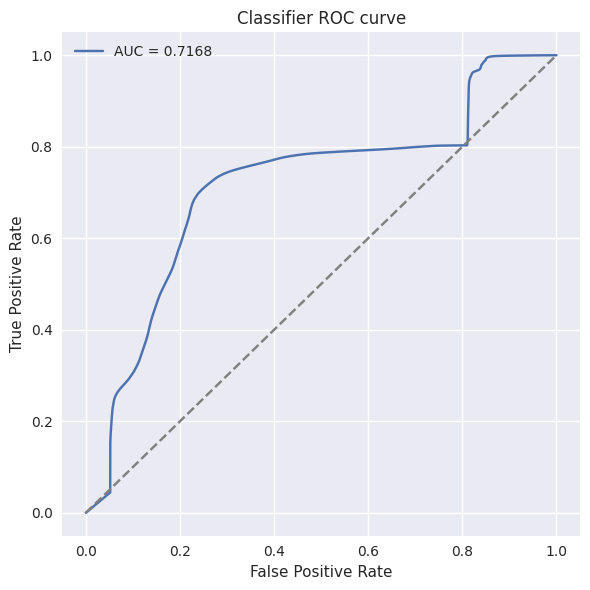

/workspace/.ts/tmp/ipykernel_73700/2316624487.py:131: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/workspace/.ts/tmp/ipykernel_73700/2316624487.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(ENSEMBLE_ROC_FIGURE_PATH, dpi=160, bbox_inches="tight")
/opt/venvs/corecore-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


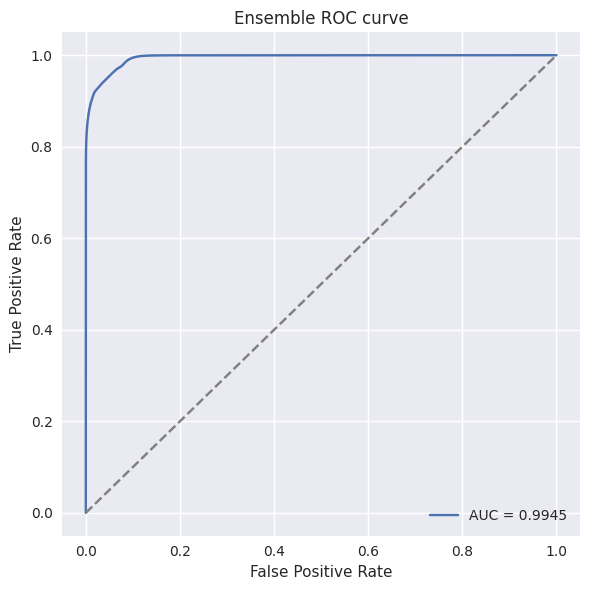

Classifier F1:      0.4963
Classifier ROC-AUC: 0.7168
Ensemble IoU:       0.8664
Ensemble DICE:      0.9284
Ensemble ROC-AUC:   0.9945
              precision    recall  f1-score   support

  background       0.97      0.99      0.98 118020781
        pore       0.96      0.90      0.93  35579219

    accuracy                           0.97 153600000
   macro avg       0.96      0.94      0.95 153600000
weighted avg       0.97      0.97      0.97 153600000



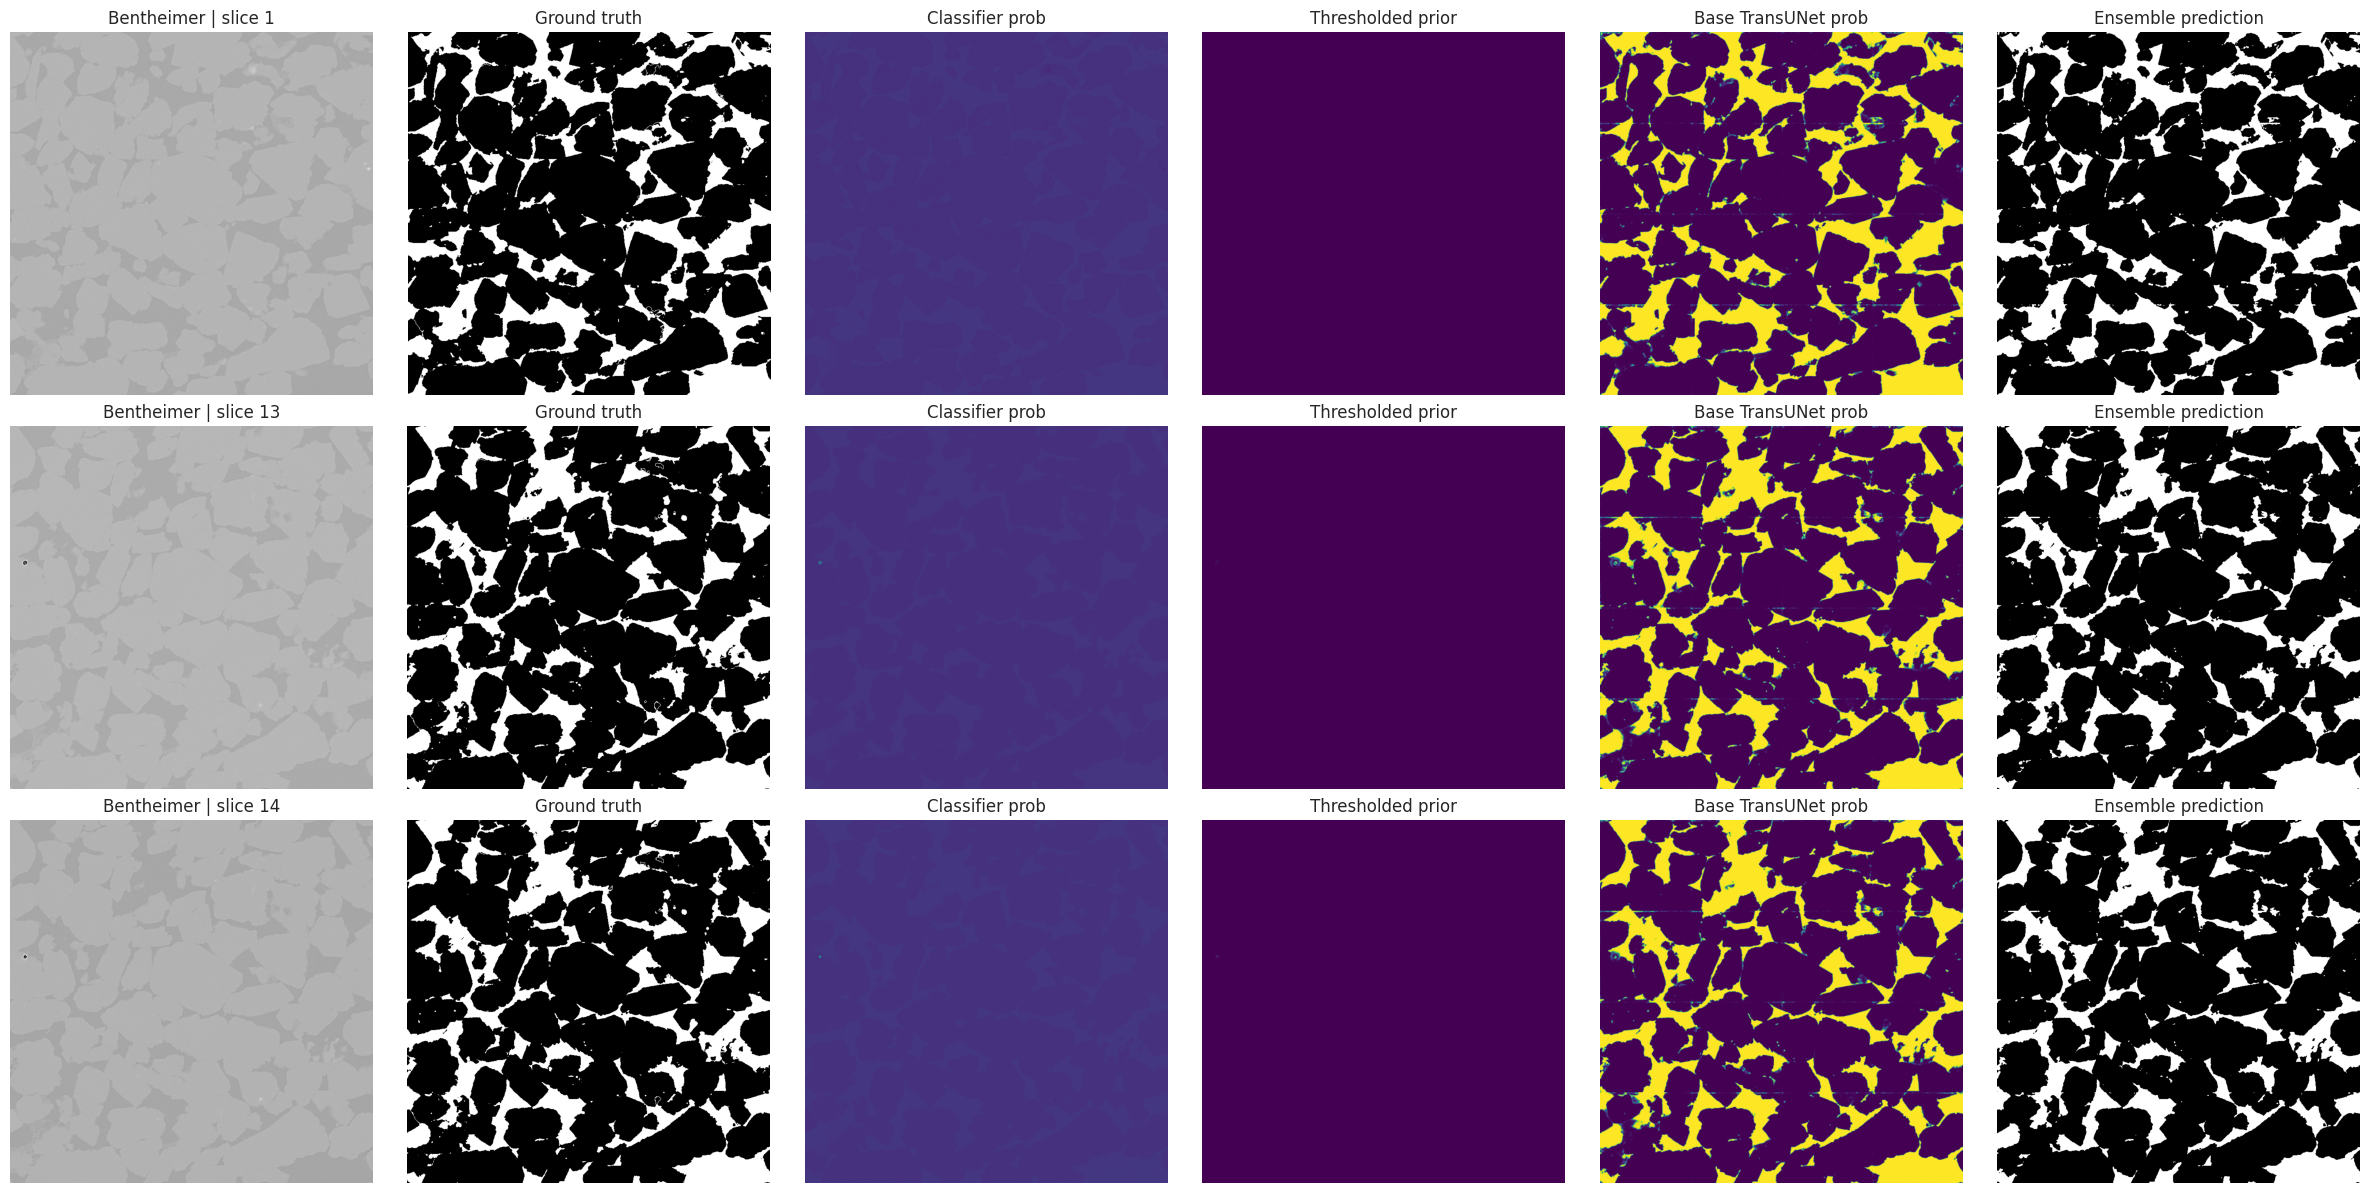

Saved classifier ROC figure to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/plots/classifier_roc_curve.png
Saved ensemble ROC figure to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/plots/ensemble_roc_curve.png
Saved validation metrics to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/metrics/validation_metrics.csv
Saved validation report to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/metrics/validation_report.txt
Saved validation predictions to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/predictions/validation_predictions.npz
Saved prediction index to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_drp421_stacking/20260328_193923/predictions/validation_prediction_index.csv
Saved preview figure to /big_data/aleksey/CoreUNet/outputs/transunet_segmentation_d

In [14]:
if not BEST_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Best stacking checkpoint was not found: {BEST_CHECKPOINT_PATH}")

checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

np.savez(
    CLASSIFIER_STATE_PATH,
    intensity_threshold=np.array([float(model.threshold_classifier.current_threshold().detach().cpu())], dtype=np.float32),
    sharpness=np.array([float(model.threshold_classifier.current_sharpness().detach().cpu())], dtype=np.float32),
    decision_threshold=np.array([CLASSIFIER_DECISION_THRESHOLD], dtype=np.float32),
    patch_size=np.array([PATCH_SIZE], dtype=np.int32),
)

reconstructed_slices = {}

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Stacking inference"):
        images = batch["image"].to(DEVICE)
        ensemble_logits, classifier_logit, classifier_prob, classifier_prior, base_prob, ensemble_prob = model.forward_with_aux(images)
        stitch_batch_predictions(
            reconstructed_slices=reconstructed_slices,
            batch=batch,
            classifier_prob=classifier_prob,
            classifier_prior=classifier_prior,
            base_prob=base_prob,
            ensemble_prob=ensemble_prob,
        )

ordered_predictions, y_true, classifier_prob_flat, ensemble_prob_flat, y_pred = flatten_reconstructed_slices(reconstructed_slices)
classifier_pred_flat = (classifier_prob_flat >= CLASSIFIER_DECISION_THRESHOLD).astype(np.uint8)

classifier_f1 = f1_score(y_true, classifier_pred_flat, average="binary", zero_division=0)
classifier_roc_auc = safe_roc_auc(y_true, classifier_prob_flat)
ensemble_iou = jaccard_score(y_true, y_pred, average="binary", zero_division=0)
ensemble_dice = f1_score(y_true, y_pred, average="binary", zero_division=0)
ensemble_roc_auc = safe_roc_auc(y_true, ensemble_prob_flat)
report_text = classification_report(
    y_true,
    y_pred,
    target_names=["background", "pore"],
    zero_division=0,
)

prediction_rows = [
    {
        "sample_name": item["sample_name"],
        "slice_idx": int(item["slice_idx"]),
        "height": int(item["image"].shape[0]),
        "width": int(item["image"].shape[1]),
    }
    for item in ordered_predictions
]
prediction_index_df = pd.DataFrame(prediction_rows)
prediction_index_df.to_csv(PREDICTION_INDEX_PATH, index=False)

pd.DataFrame(
    [
        {
            "classifier_f1": classifier_f1,
            "classifier_roc_auc": classifier_roc_auc,
            "classifier_decision_threshold": CLASSIFIER_DECISION_THRESHOLD,
            "ensemble_iou": ensemble_iou,
            "ensemble_dice": ensemble_dice,
            "ensemble_roc_auc": ensemble_roc_auc,
            "checkpoint_path": str(BEST_CHECKPOINT_PATH),
            "n_slices": len(prediction_index_df),
            "patch_size": PATCH_SIZE,
        }
    ]
).to_csv(VALIDATION_METRICS_PATH, index=False)

with open(VALIDATION_REPORT_PATH, "w", encoding="utf-8") as output:
    output.write(
        "Patch-wise validation setup\n"
        f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}\n"
        "- Border patches smaller than the target size are padded before inference\n"
        "- Padded pixels are excluded from losses and cropped away during reconstruction\n\n"
        "Classifier metrics\n"
        f"F1: {classifier_f1:.4f}\n"
        f"ROC-AUC: {classifier_roc_auc:.4f}\n"
        f"Decision threshold: {CLASSIFIER_DECISION_THRESHOLD:.2f}\n\n"
        "Ensemble metrics\n"
        f"IoU: {ensemble_iou:.4f}\n"
        f"DICE: {ensemble_dice:.4f}\n"
        f"ROC-AUC: {ensemble_roc_auc:.4f}\n\n"
        "Probability naming\n"
        "- classifier_prob: raw sigmoid probability from the learnable threshold classifier\n"
        "- classifier_prior: threshold-adjusted probability passed into the ensemble fusion head\n\n"
        "Ensemble classification report\n"
        + report_text
    )

np.savez_compressed(
    PREDICTION_ARCHIVE_PATH,
    images=np.array([item["image"] for item in ordered_predictions], dtype=object),
    masks=np.array([item["mask"] for item in ordered_predictions], dtype=object),
    preds=np.array([item["pred"] for item in ordered_predictions], dtype=object),
    classifier_prob=np.array([item["classifier_prob"] for item in ordered_predictions], dtype=object),
    classifier_prior=np.array([item["classifier_prior"] for item in ordered_predictions], dtype=object),
    base_unet_prob=np.array([item["base_prob"] for item in ordered_predictions], dtype=object),
    ensemble_prob=np.array([item["ensemble_prob"] for item in ordered_predictions], dtype=object),
    sample_name=prediction_index_df["sample_name"].to_numpy(dtype=str),
    slice_idx=prediction_index_df["slice_idx"].to_numpy(dtype=np.int32),
    height=prediction_index_df["height"].to_numpy(dtype=np.int32),
    width=prediction_index_df["width"].to_numpy(dtype=np.int32),
)

if np.unique(y_true).size >= 2:
    classifier_fpr, classifier_tpr, _ = roc_curve(y_true, classifier_prob_flat)
    fig = plt.figure(figsize=(6, 6))
    plt.plot(classifier_fpr, classifier_tpr, label=f"AUC = {classifier_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Classifier ROC curve")
    plt.legend()
    plt.tight_layout()
    fig.savefig(CLASSIFIER_ROC_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

    ensemble_fpr, ensemble_tpr, _ = roc_curve(y_true, ensemble_prob_flat)
    fig = plt.figure(figsize=(6, 6))
    plt.plot(ensemble_fpr, ensemble_tpr, label=f"AUC = {ensemble_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Ensemble ROC curve")
    plt.legend()
    plt.tight_layout()
    fig.savefig(ENSEMBLE_ROC_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()
else:
    fig = plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.text(0.5, 0.5, "ROC is undefined\nfor a single validation class", ha="center", va="center")
    plt.title("Classifier ROC curve")
    plt.tight_layout()
    fig.savefig(CLASSIFIER_ROC_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

    fig = plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.text(0.5, 0.5, "ROC is undefined\nfor a single validation class", ha="center", va="center")
    plt.title("Ensemble ROC curve")
    plt.tight_layout()
    fig.savefig(ENSEMBLE_ROC_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

print(f"Classifier F1:      {classifier_f1:.4f}")
print(f"Classifier ROC-AUC: {classifier_roc_auc:.4f}")
print(f"Ensemble IoU:       {ensemble_iou:.4f}")
print(f"Ensemble DICE:      {ensemble_dice:.4f}")
print(f"Ensemble ROC-AUC:   {ensemble_roc_auc:.4f}")
print(report_text)

preview_items = ordered_predictions[:3]
fig, axes = plt.subplots(len(preview_items), 6, figsize=(24, 4 * len(preview_items)))
if len(preview_items) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, item in enumerate(preview_items):
    axes[row, 0].imshow(item["image"], cmap="gray")
    axes[row, 0].set_title(f"{item['sample_name']} | slice {item['slice_idx']}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(item["mask"], cmap="gray")
    axes[row, 1].set_title("Ground truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(item["classifier_prob"], cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Classifier prob")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(item["classifier_prior"], cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 3].set_title("Thresholded prior")
    axes[row, 3].axis("off")

    axes[row, 4].imshow(item["base_prob"], cmap="viridis", vmin=0.0, vmax=1.0)
    axes[row, 4].set_title("Base TransUNet prob")
    axes[row, 4].axis("off")

    axes[row, 5].imshow(item["pred"], cmap="gray")
    axes[row, 5].set_title("Ensemble prediction")
    axes[row, 5].axis("off")

plt.tight_layout()
fig.savefig(PREVIEW_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved classifier ROC figure to {CLASSIFIER_ROC_FIGURE_PATH}")
print(f"Saved ensemble ROC figure to {ENSEMBLE_ROC_FIGURE_PATH}")
print(f"Saved validation metrics to {VALIDATION_METRICS_PATH}")
print(f"Saved validation report to {VALIDATION_REPORT_PATH}")
print(f"Saved validation predictions to {PREDICTION_ARCHIVE_PATH}")
print(f"Saved prediction index to {PREDICTION_INDEX_PATH}")
print(f"Saved preview figure to {PREVIEW_FIGURE_PATH}")
print(f"Saved classifier state to {CLASSIFIER_STATE_PATH}")